Total thermocouples found in layers [6177, 5177, 4727]: 147


c:\Users\sahoo\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\sahoo\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


KeyboardInterrupt: 

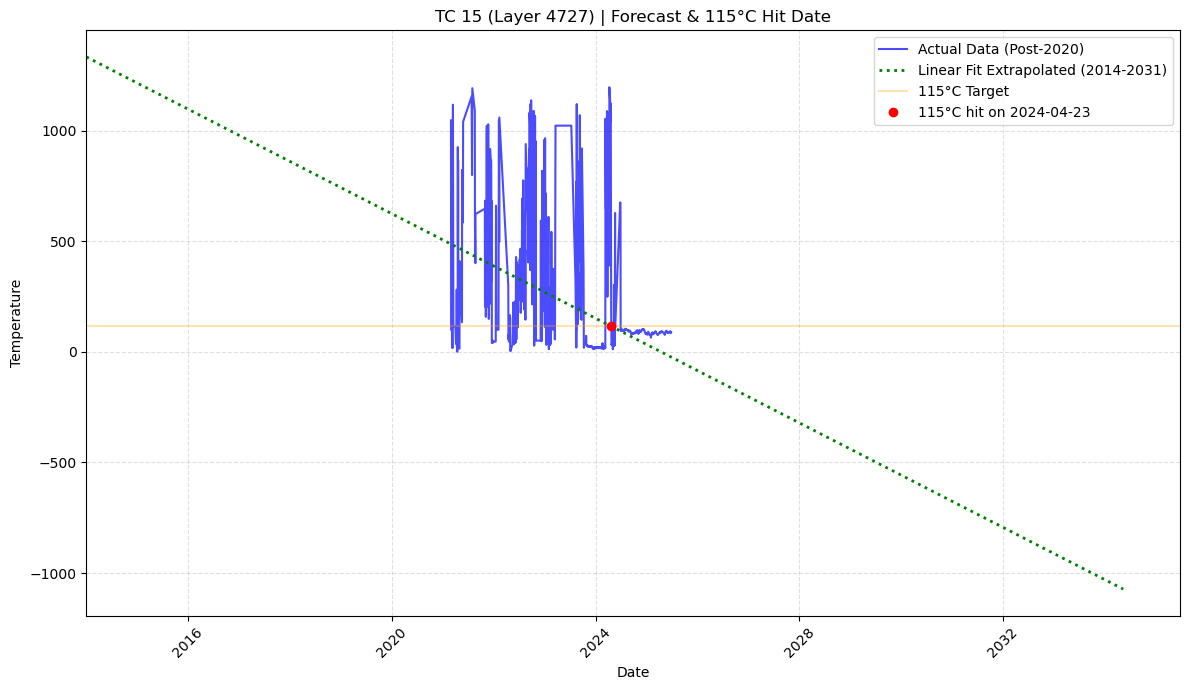

In [4]:



# Read the CSV files
df = pd.read_csv("value_rf_imputed.csv")
tc_metadata = pd.read_csv("thermocouples.csv")

# Convert date column
df["MEASUREDATE"] = pd.to_datetime(df["MEASUREDATE"], dayfirst=True)

# Filter criteria: 
# 1. Date after 2020
# 2. Layers: 6177, 5177, 4727
target_layers = [6177, 5177, 4727]
filtered_tc_ids = tc_metadata[tc_metadata['Z'].isin(target_layers)]['no.'].unique()

df_filtered = df[(df["MEASUREDATE"] > "2020-12-31") & (df["Sl. No."].isin(filtered_tc_ids))].copy()

# Store layer mapping for plot titles
tc_layer_map = tc_metadata.set_index('no.')['Z'].to_dict()

# Create folder to store plots
output_folder = "Thermocouple_Plots_Advanced"
os.makedirs(output_folder, exist_ok=True)

# Get unique thermocouples
thermocouples = df_filtered["Sl. No."].unique()
print(f"Total thermocouples found in layers {target_layers}: {len(thermocouples)}")

# Custom start date for extrapolation
start_extrap_date = pd.to_datetime("2014-01-01")

# List to store intersection results
intersection_results = []

for tc in thermocouples:
    # Filter and sort data for the current thermocouple
    tc_data = df_filtered[df_filtered["Sl. No."] == tc].sort_values("MEASUREDATE").dropna(subset=["VALUE"])
    
    if len(tc_data) < 2:
        continue
        
    y = tc_data["VALUE"].values
    x_train = np.arange(len(y)).reshape(-1, 1)
    
    # 1. Advanced Forecast: Exponential Smoothing
    forecast_days_forward = 365 * 10
    try:
        model_es = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=365)
        fit_es = model_es.fit()
        forecast_es = fit_es.forecast(forecast_days_forward)
    except:
        try:
            model_es = ExponentialSmoothing(y, trend='add')
            fit_es = model_es.fit()
            forecast_es = fit_es.forecast(forecast_days_forward)
        except:
            forecast_es = np.full(forecast_days_forward, y[-1])

    # 2. Linear Fit Extrapolation
    model_lr = LinearRegression()
    model_lr.fit(x_train, y)
    
    m = model_lr.coef_[0]
    c = model_lr.intercept_
    
    # Backward/Forward plot range
    first_data_date = tc_data["MEASUREDATE"].min()
    days_backward = (first_data_date - start_extrap_date).days
    x_plot = np.arange(-days_backward, len(y) + forecast_days_forward).reshape(-1, 1)
    line_lr_full = model_lr.predict(x_plot)
    
    # 3. Intersection Calculation: When Linear Fit hits 115 degrees
    # Linear Equation: y = mx + c. To find x where y = 115:
    if abs(m) > 1e-9:
        # Solving mx + c = 115 => x = (115 - c) / m
        # Note: c here is y at x=0 (the first data point in tc_data)
        days_from_first_point = (115 - c) / m
        intersection_date = first_data_date + pd.Timedelta(days=float(days_from_first_point))
    else:
        intersection_date = None

    layer = tc_layer_map.get(tc, "Unknown")
    intersection_results.append({
        "Sl. No.": tc,
        "Layer": layer,
        "Intersection_Date_115C": intersection_date,
        "Trend_Slope": m
    })

    # -------- Create timelines --------
    dates_all = pd.date_range(start=start_extrap_date, periods=len(x_plot), freq='D')
    dates_hist = tc_data["MEASUREDATE"]
    dates_future = pd.date_range(start=dates_hist.max() + pd.DateOffset(days=1), periods=forecast_days_forward, freq='D')
    
    # Use numpy to concatenate for plotting
    dates_all_vals = np.concatenate([dates_hist.values, dates_future.values])
    
    # -------- Plot --------
    plt.figure(figsize=(12,7))
    plt.plot(dates_hist.values, y, label="Actual Data (Post-2020)", color='blue', alpha=0.7)
    #lt.plot(dates_future.values, forecast_es, linestyle='--', color='red', label="Advanced Forecast (Forward)")
    plt.plot(dates_all.values, line_lr_full, linestyle=':', color='green', label="Linear Fit Extrapolated (2014-2031)", linewidth=2)
    
    # Mark intersection point if it's within plot range
    if intersection_date and start_extrap_date <= intersection_date <= dates_future.max():
        plt.axhline(y=115, color='orange', linestyle='-', alpha=0.3, label="115°C Target")
        plt.plot(intersection_date, 115, 'ro', label=f"115°C hit on {intersection_date.strftime('%Y-%m-%d')}")

    plt.xlabel("Date")
    plt.ylabel("Temperature")
    plt.title(f"TC {tc} (Layer {layer}) | Forecast & 115°C Hit Date")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xticks(rotation=45)
    plt.xlim(start_extrap_date, dates_future.max())
    plt.tight_layout()
    
    plt.savefig(f"{output_folder}/TC_{tc}.png", dpi=200)
    plt.close()

# Save results to CSV
results_df = pd.DataFrame(intersection_results)
results_df.to_csv("intersection_dates_115C.csv", index=False)
print(f'All plots saved in: {output_folder}')
print(f'Intersection dates saved in: intersection_dates_115C.csv')

# Display top hits (upcoming or historical)
print("\n--- Top 10 Intersection Dates at 115°C ---")
print(results_df.dropna(subset=['Intersection_Date_115C']).sort_values('Intersection_Date_115C').head(10))

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression



# Code to plot Delta x (erosion distance) vs time for a user-defined thermocouple
# Formula: Delta T / 0.25 = delta x


df = pd.read_csv("value_rf_imputed.csv")
tc_metadata = pd.read_csv("thermocouples.csv")

# Convert date column
df["MEASUREDATE"] = pd.to_datetime(df["MEASUREDATE"], dayfirst=True)




try:
    user_tc = int(input("Enter Thermocouple Sl. No.:37, 38, 77, 85, 89, 93, 183, 191, 202 "))
except ValueError:
    print("Please enter a valid integer.")
    user_tc = None

if user_tc is not None and 'df' in globals() and user_tc in df["Sl. No."].values:
    # Filter data for this thermocouple
    tc_data_user = df[df["Sl. No."] == user_tc].sort_values("MEASUREDATE").dropna(subset=["VALUE"]).copy()
    
    if len(tc_data_user) > 0:
        # Calculate Delta T
        # Assuming Delta T is the difference from the initial temperature value
        initial_temp = tc_data_user["VALUE"].iloc[0]
        tc_data_user["Delta_T"] = tc_data_user["VALUE"] - initial_temp
        
        # Calculate Delta x (erosion distance)
        # Formula: Delta T / 0.25 = delta x
        tc_data_user["Delta_x"] = tc_data_user["Delta_T"] / 0.25
        
        # Plot Delta x vs time
        plt.figure(figsize=(10, 6))
        plt.plot(tc_data_user["MEASUREDATE"], tc_data_user["Delta_x"], marker='.', linestyle='-', color='purple', alpha=0.7)
        plt.xlabel("Date")
        plt.ylabel("Delta x (Erosion Distance)")
        plt.title(f"Erosion Distance (Delta x) vs Time for Thermocouple {user_tc}")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid data for this thermocouple.")
elif user_tc is not None and 'df' not in globals():
    print("Dataframe 'df' is not defined. Please run the previous cell first.")
elif user_tc is not None:
    print("Thermocouple not found in the dataset.")


Please enter a valid integer.


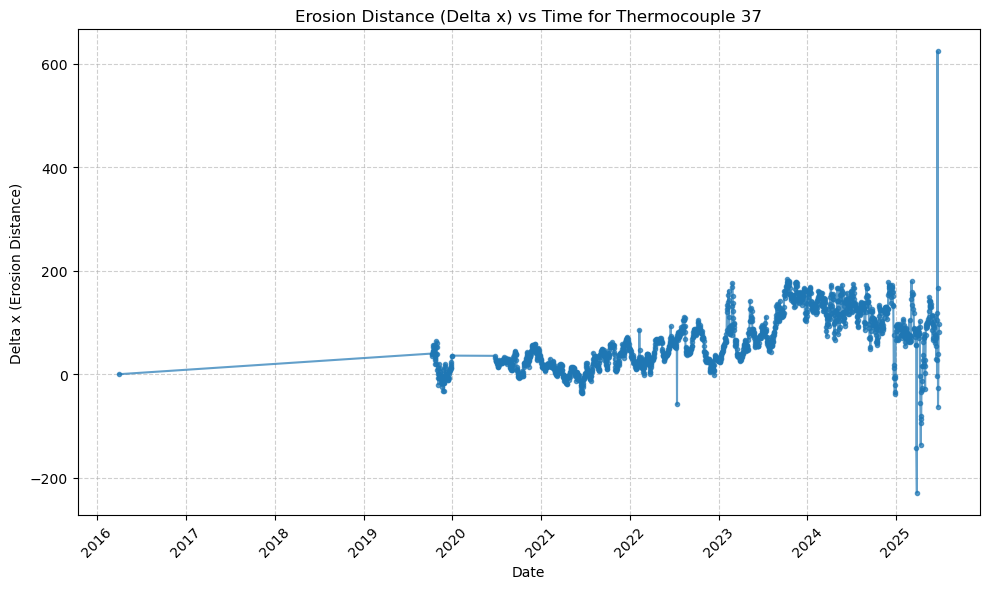

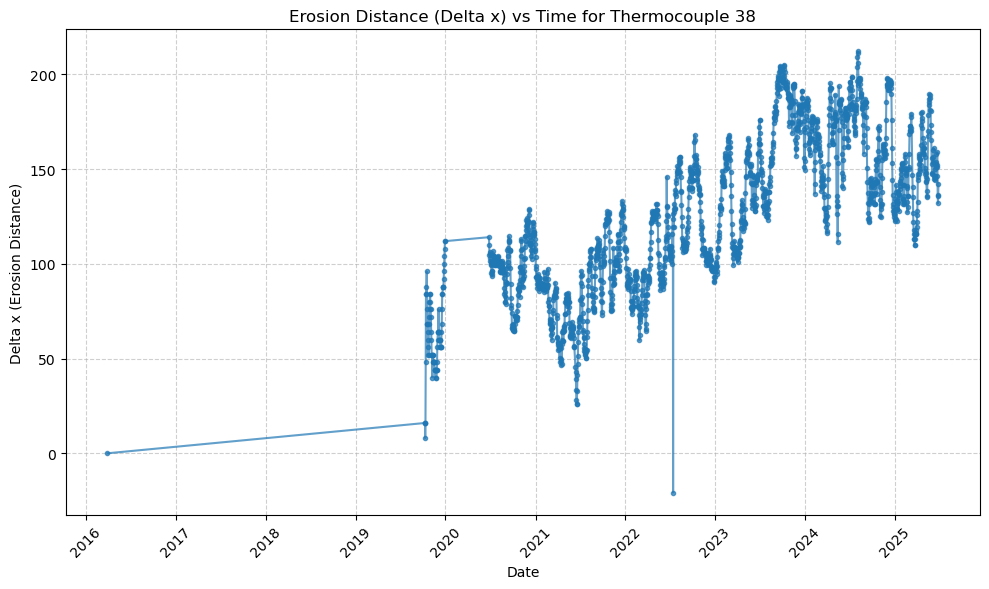

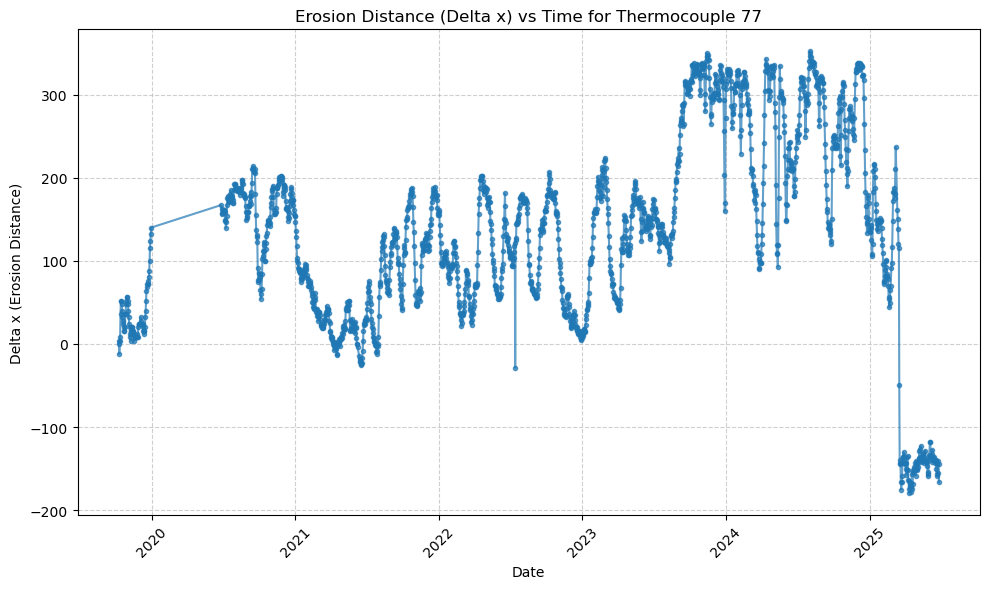

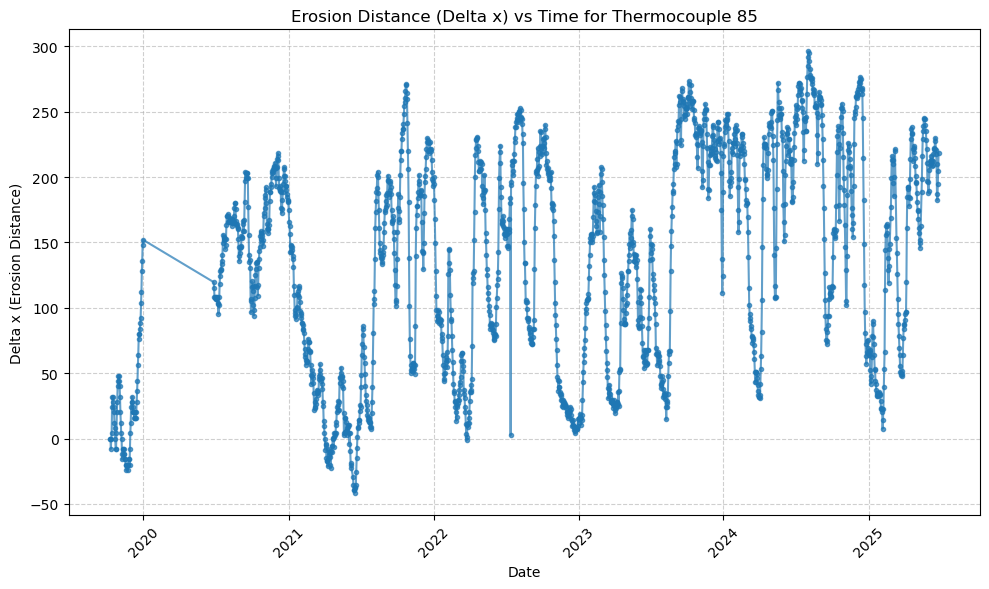

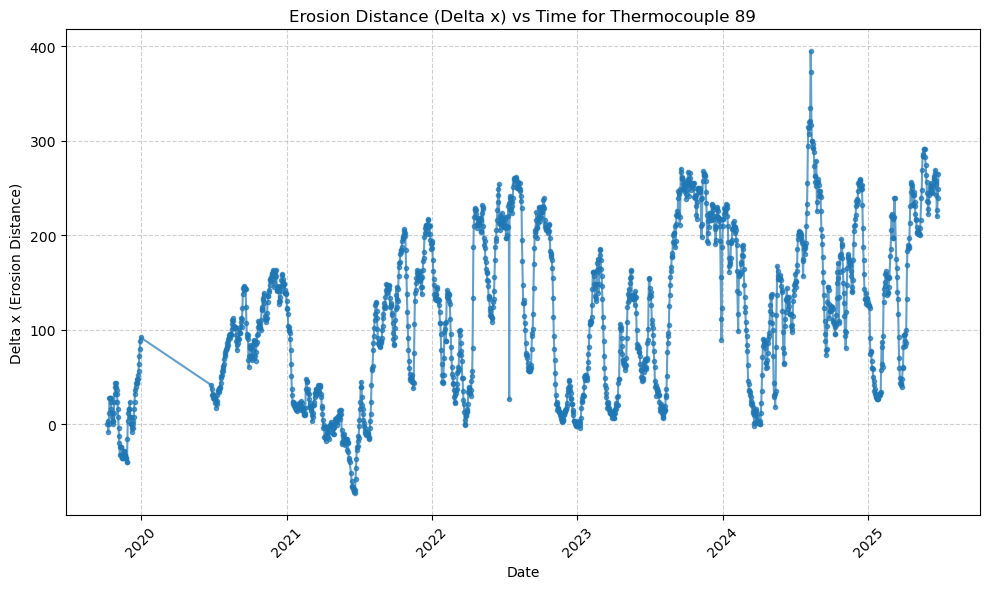

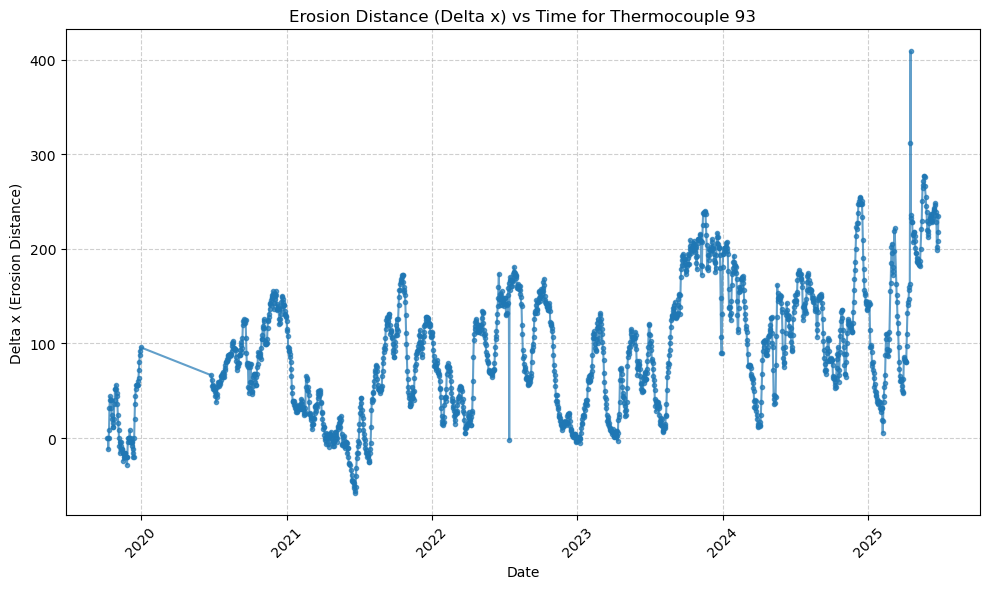

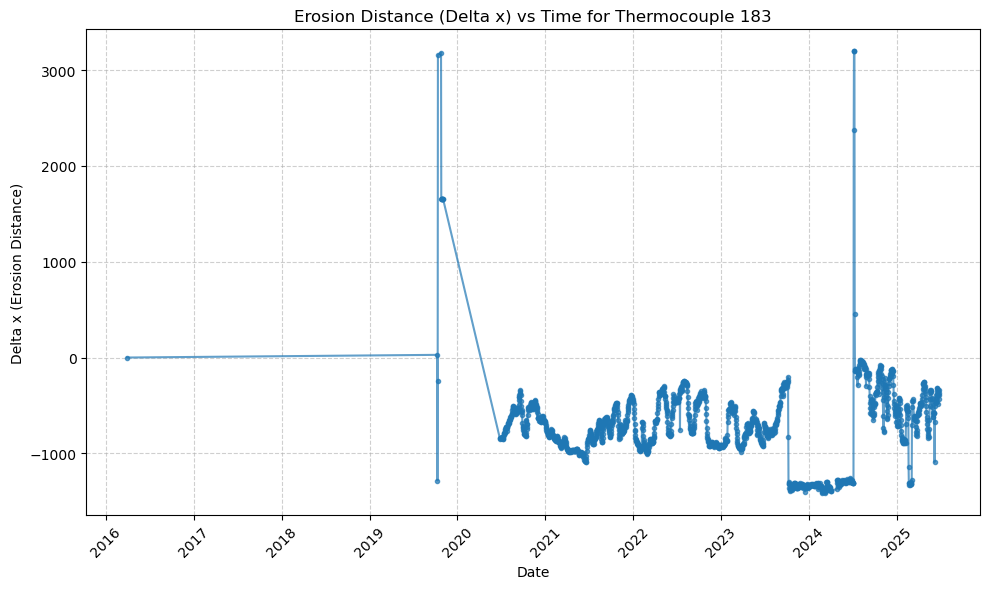

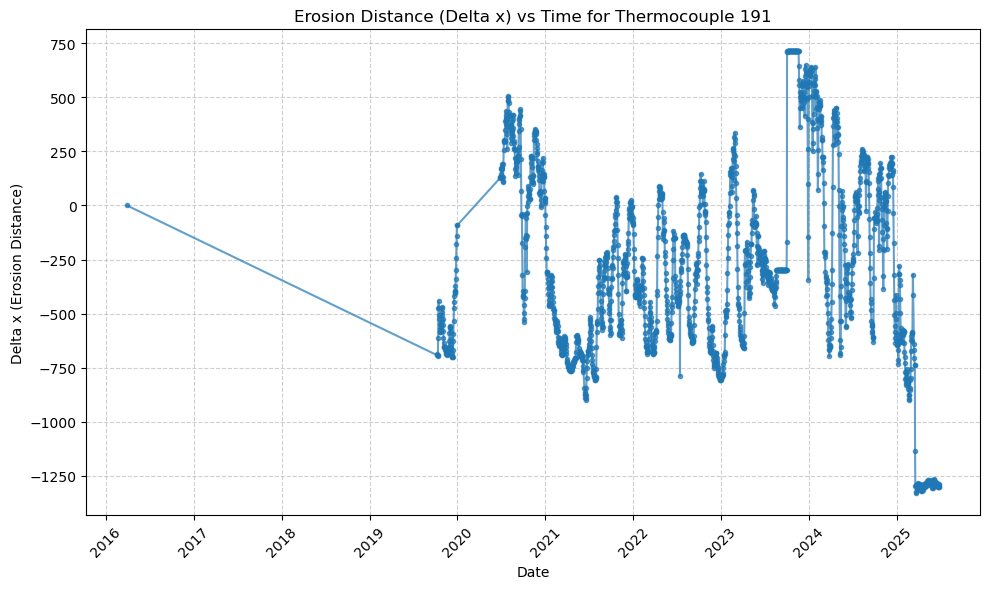

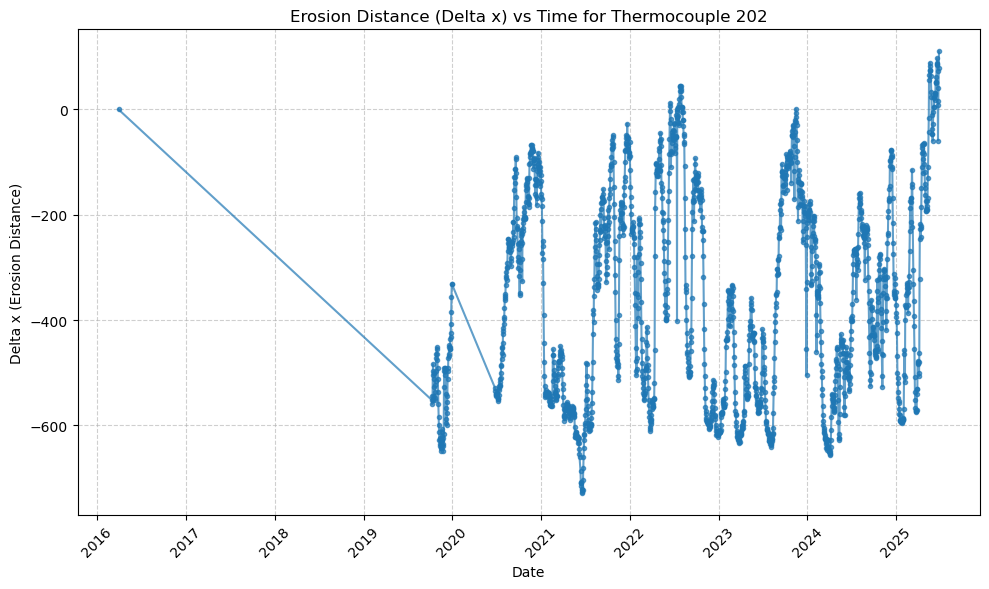

In [6]:
# Code to plot Delta x (erosion distance) vs time for multiple user-defined thermocouples
# Formula: Delta T / 0.25 = delta x

user_input = input("Enter Thermocouple Sl. No. separated by commas (e.g., 101, 102, 103): ")
try:
    if user_input.strip():
        user_tc_list = [int(x.strip()) for x in user_input.split(',')] 
    else:
        user_tc_list = []
except ValueError:
    print("Please enter valid integers separated by commas.")
    user_tc_list = []

if user_tc_list and 'df' in globals():
    for user_tc in user_tc_list:
        if user_tc in df["Sl. No."].values:
            # Filter data for this thermocouple
            tc_data_user = df[df["Sl. No."] == user_tc].sort_values("MEASUREDATE").dropna(subset=["VALUE"]).copy()
            
            if len(tc_data_user) > 0:
                # Calculate Delta T
                # Assuming Delta T is the difference from the initial temperature value
                initial_temp = tc_data_user["VALUE"].iloc[0]
                tc_data_user["Delta_T"] = tc_data_user["VALUE"] - initial_temp
                
                # Calculate Delta x (erosion distance)
                # Formula: Delta T / 0.25 = delta x
                tc_data_user["Delta_x"] = tc_data_user["Delta_T"] / 0.25
                
                # Plot Delta x vs time
                plt.figure(figsize=(10, 6))
                plt.plot(tc_data_user["MEASUREDATE"], tc_data_user["Delta_x"], marker='.', linestyle='-', alpha=0.7)
                plt.xlabel("Date")
                plt.ylabel("Delta x (Erosion Distance)")
                plt.title(f"Erosion Distance (Delta x) vs Time for Thermocouple {user_tc}")
                plt.grid(True, linestyle='--', alpha=0.6)
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
            else:
                print(f"Not enough valid data for thermocouple {user_tc}.")
        else:
            print(f"Thermocouple {user_tc} not found in the dataset.")
elif user_tc_list and 'df' not in globals():
    print("Dataframe 'df' is not defined. Please run the previous cell first.")


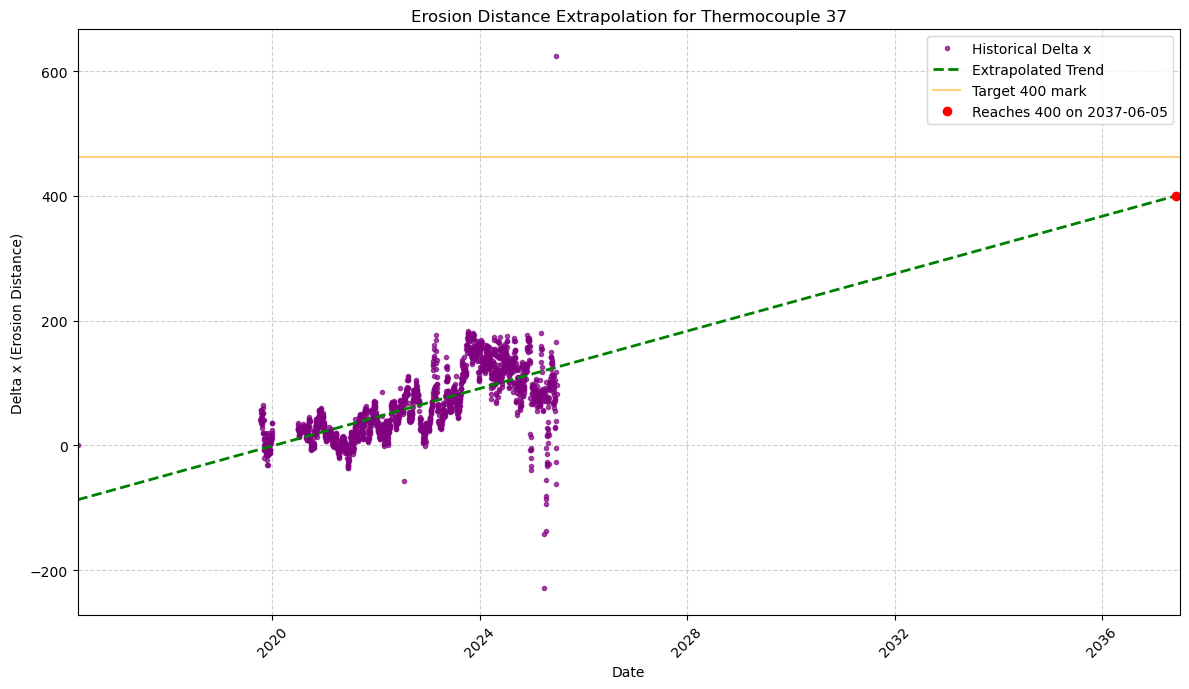

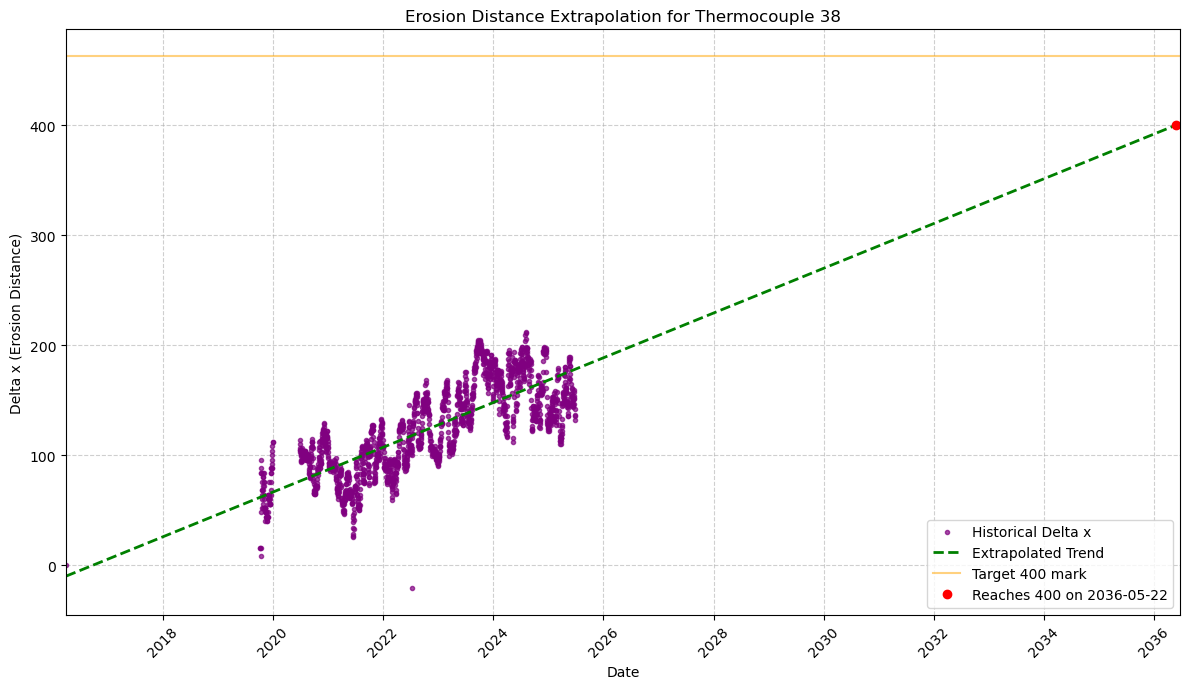

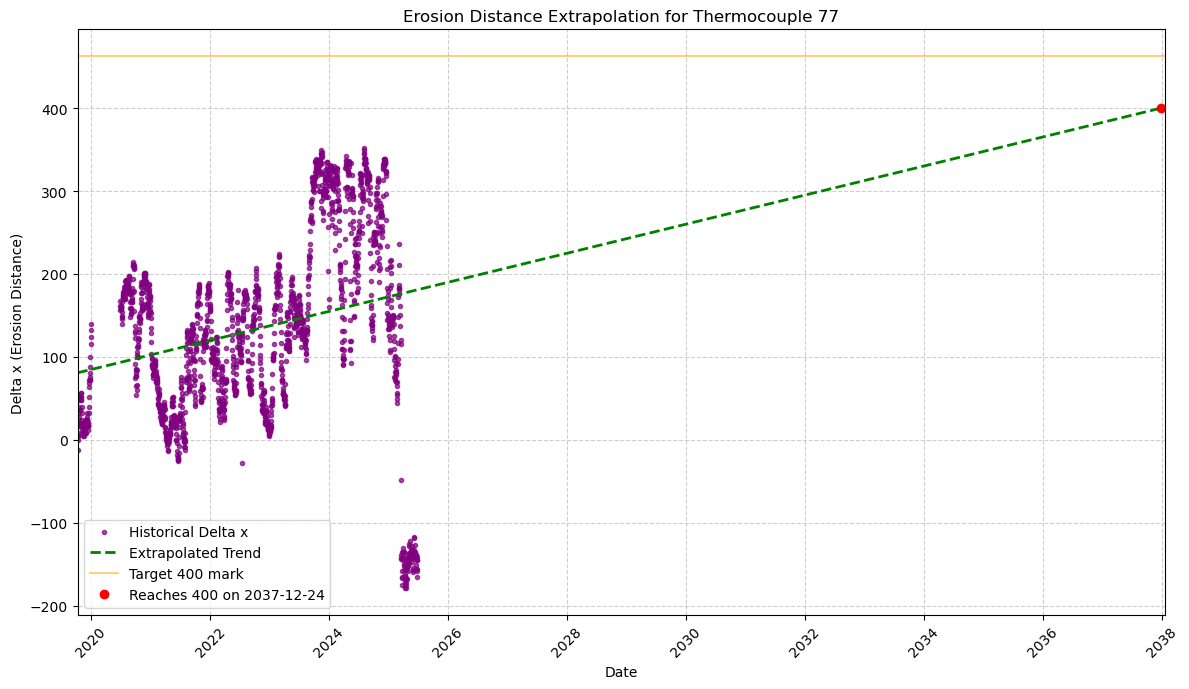

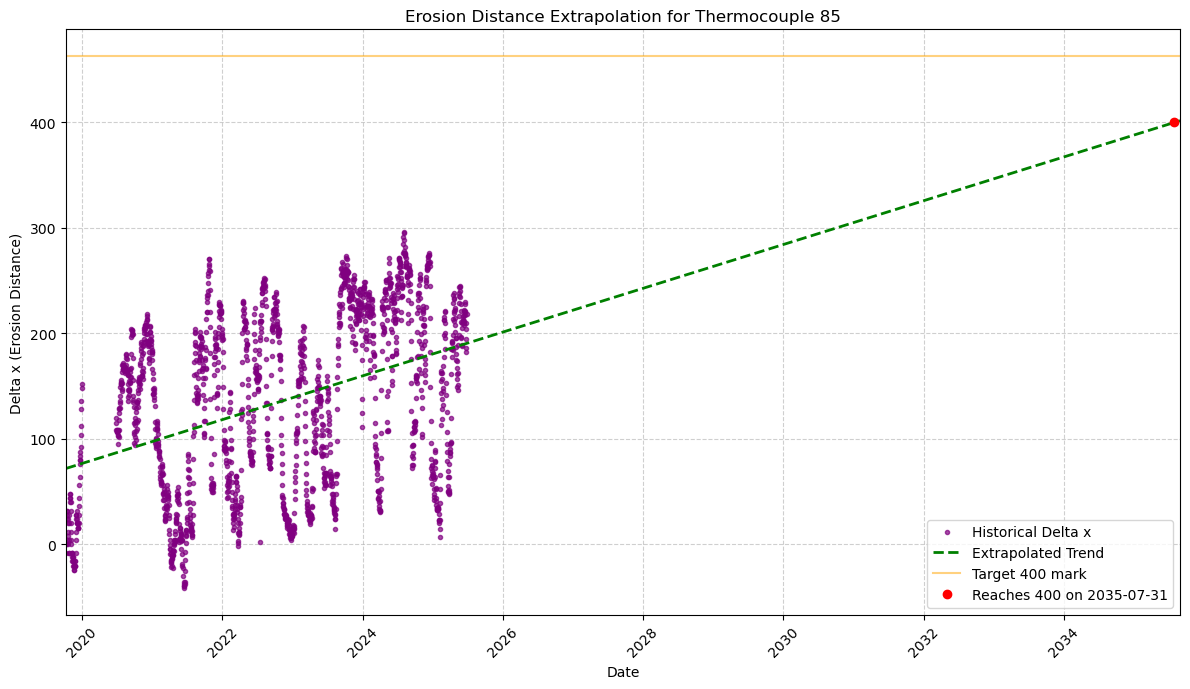

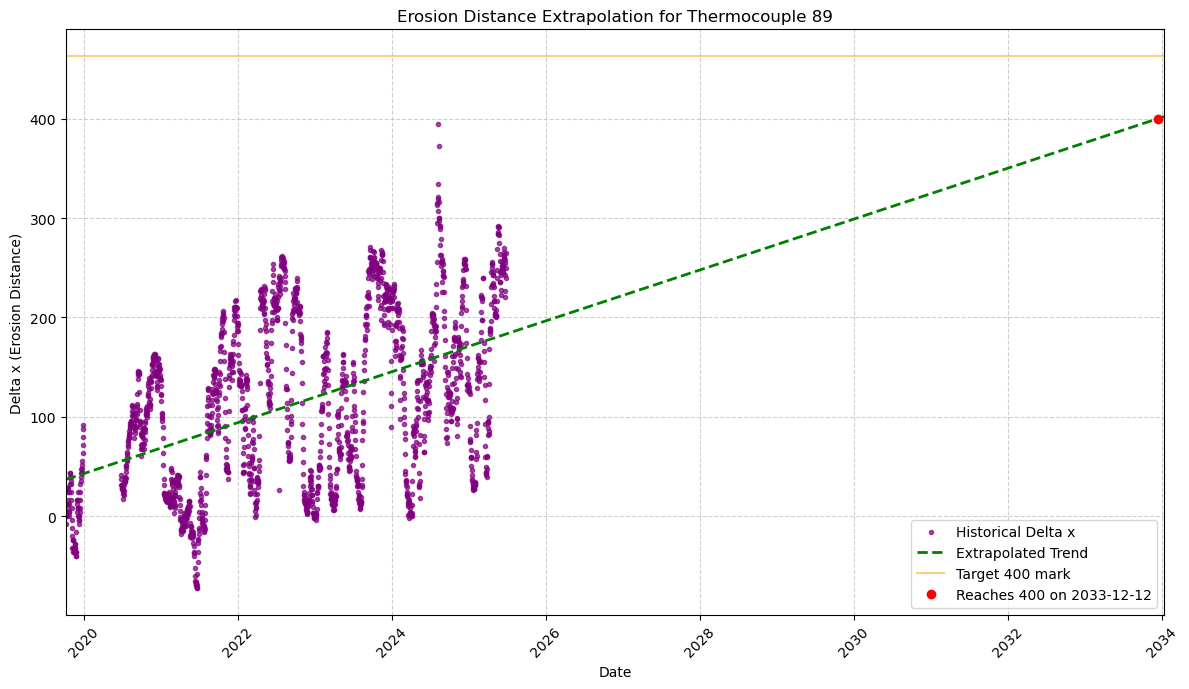

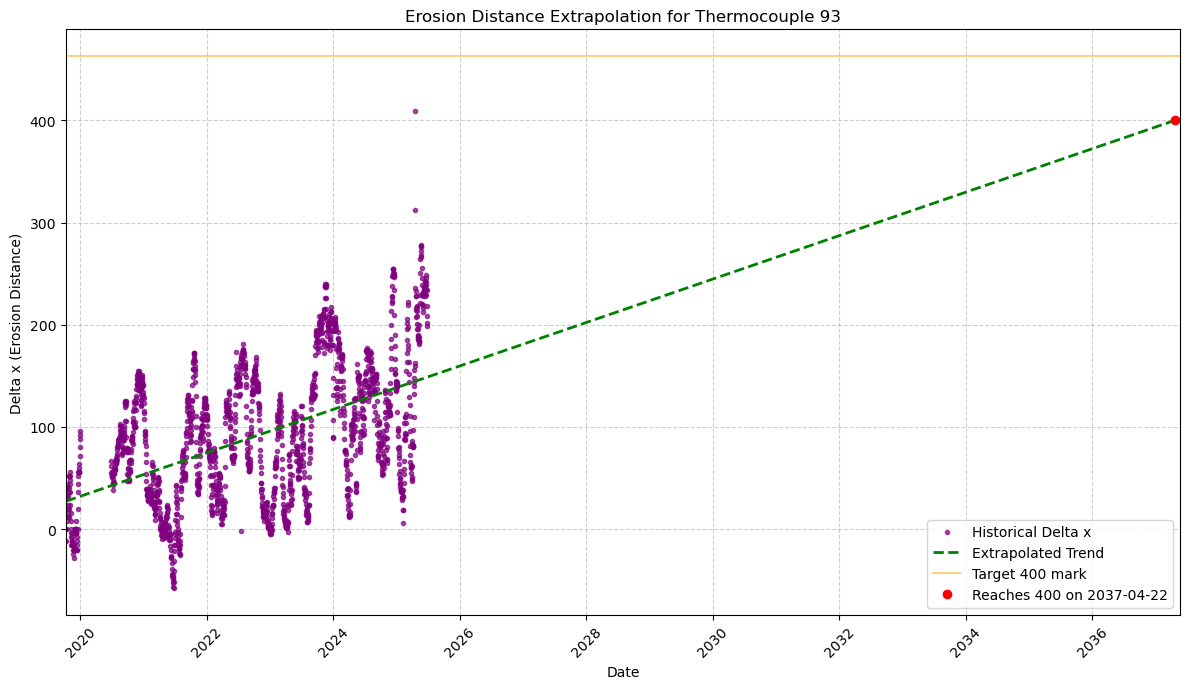

Erosion trend is negative or flat for thermocouple 183, will not reach 400.


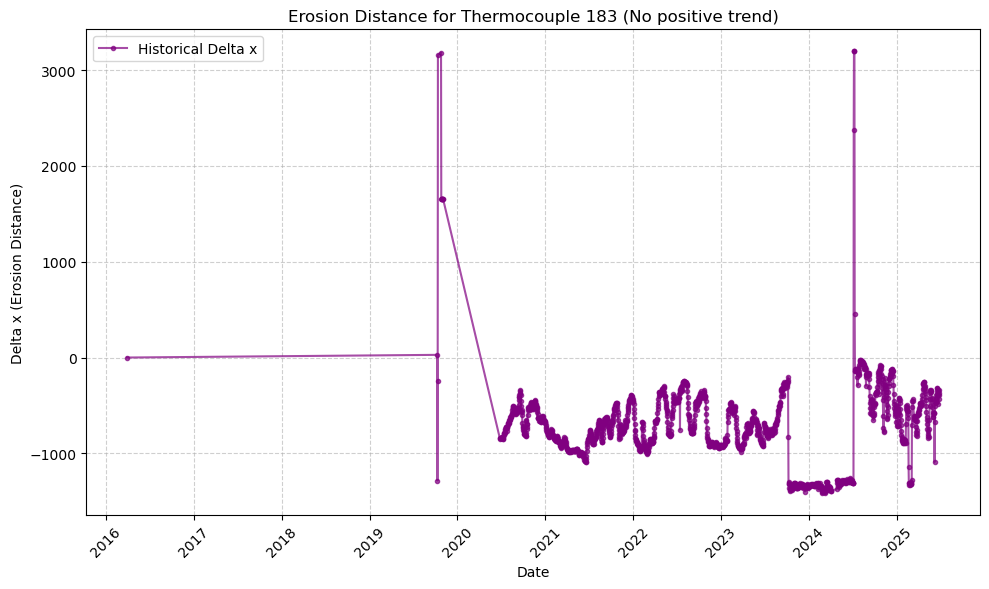

Erosion trend is negative or flat for thermocouple 191, will not reach 400.


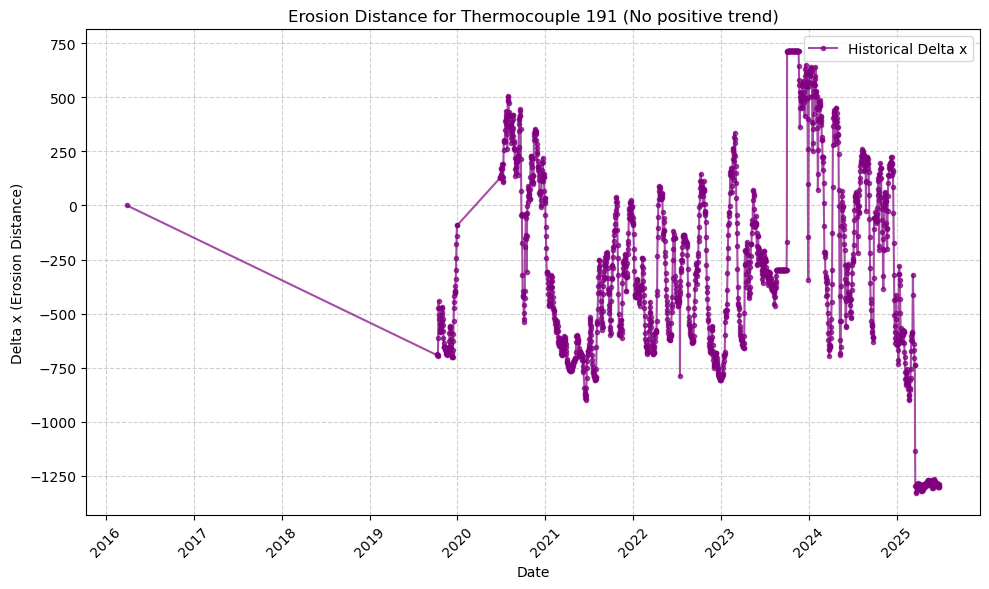

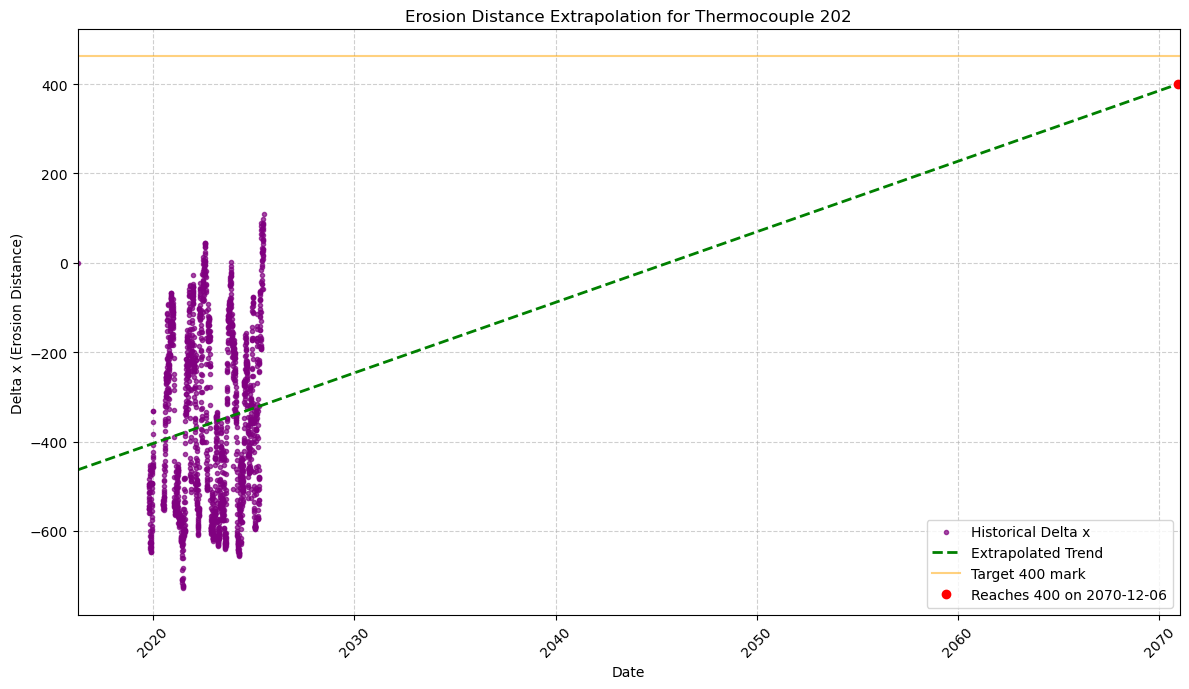

In [8]:
# Code to plot and extrapolate Delta x (erosion distance) vs time for multiple user-defined thermocouples
# Formula: Delta T / 0.25 = delta x
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

user_input = input("Enter Thermocouple Sl. No. separated by commas (e.g., 101, 102, 103): ")
try:
    if user_input.strip():
        user_tc_list = [int(x.strip()) for x in user_input.split(',')] 
    else:
        user_tc_list = []
except ValueError:
    print("Please enter valid integers separated by commas.")
    user_tc_list = []

if user_tc_list and 'df' in globals():
    for user_tc in user_tc_list:
        if user_tc in df["Sl. No."].values:
            # Filter data for this thermocouple
            tc_data_user = df[df["Sl. No."] == user_tc].sort_values("MEASUREDATE").dropna(subset=["VALUE"]).copy()
            
            if len(tc_data_user) > 1:
                initial_temp = tc_data_user["VALUE"].iloc[0]
                tc_data_user["Delta_T"] = tc_data_user["VALUE"] - initial_temp
                tc_data_user["Delta_x"] = tc_data_user["Delta_T"] / 0.25
                
                first_date = tc_data_user["MEASUREDATE"].min()
                tc_data_user["Days"] = (tc_data_user["MEASUREDATE"] - first_date).dt.days
                
                X = tc_data_user[["Days"]].values
                y = tc_data_user["Delta_x"].values
                
                model_lr = LinearRegression()
                model_lr.fit(X, y)
                m = model_lr.coef_[0]
                c = model_lr.intercept_
                
                if m > 1e-9:
                    days_to_target = (400 - c) / m
                    target_date = first_date + pd.Timedelta(days=float(days_to_target))
                    
                    end_date = max(tc_data_user["MEASUREDATE"].max(), target_date)
                    forecast_days = (end_date - first_date).days
                    
                    # Create extrapolation points until a little past the target date
                    X_extrap = np.arange(0, forecast_days + 30).reshape(-1, 1)
                    y_extrap = model_lr.predict(X_extrap)
                    dates_extrap = [first_date + pd.Timedelta(days=float(d)) for d in X_extrap.flatten()]
                    
                    plt.figure(figsize=(12, 7))
                    plt.plot(tc_data_user["MEASUREDATE"], tc_data_user["Delta_x"], marker='.', linestyle='none', color='purple', alpha=0.7, label='Historical Delta x')
                    plt.plot(dates_extrap, y_extrap, linestyle='--', color='green', label="Extrapolated Trend", linewidth=2)
                    
                    plt.axhline(y=463, color='orange', linestyle='-', alpha=0.5, label="Target 400 mark")
                    plt.plot(target_date, 400, 'ro', label=f"Reaches 400 on {target_date.strftime('%Y-%m-%d')}")
                    
                    plt.xlabel("Date")
                    plt.ylabel("Delta x (Erosion Distance)")
                    plt.title(f"Erosion Distance Extrapolation for Thermocouple {user_tc}")
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    plt.xticks(rotation=45)
                    plt.xlim(min(dates_extrap), max(dates_extrap))
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"Erosion trend is negative or flat for thermocouple {user_tc}, will not reach 400.")
                    plt.figure(figsize=(10, 6))
                    plt.plot(tc_data_user["MEASUREDATE"], tc_data_user["Delta_x"], marker='.', linestyle='-', color='purple', alpha=0.7, label='Historical Delta x')
                    plt.xlabel("Date")
                    plt.ylabel("Delta x (Erosion Distance)")
                    plt.title(f"Erosion Distance for Thermocouple {user_tc} (No positive trend)")
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    plt.show()
            else:
                print(f"Not enough valid data for thermocouple {user_tc} to perform regression.")
        else:
            print(f"Thermocouple {user_tc} not found in the dataset.")
elif user_tc_list and 'df' not in globals():
    print("Dataframe 'df' is not defined. Please run the previous cell first.")


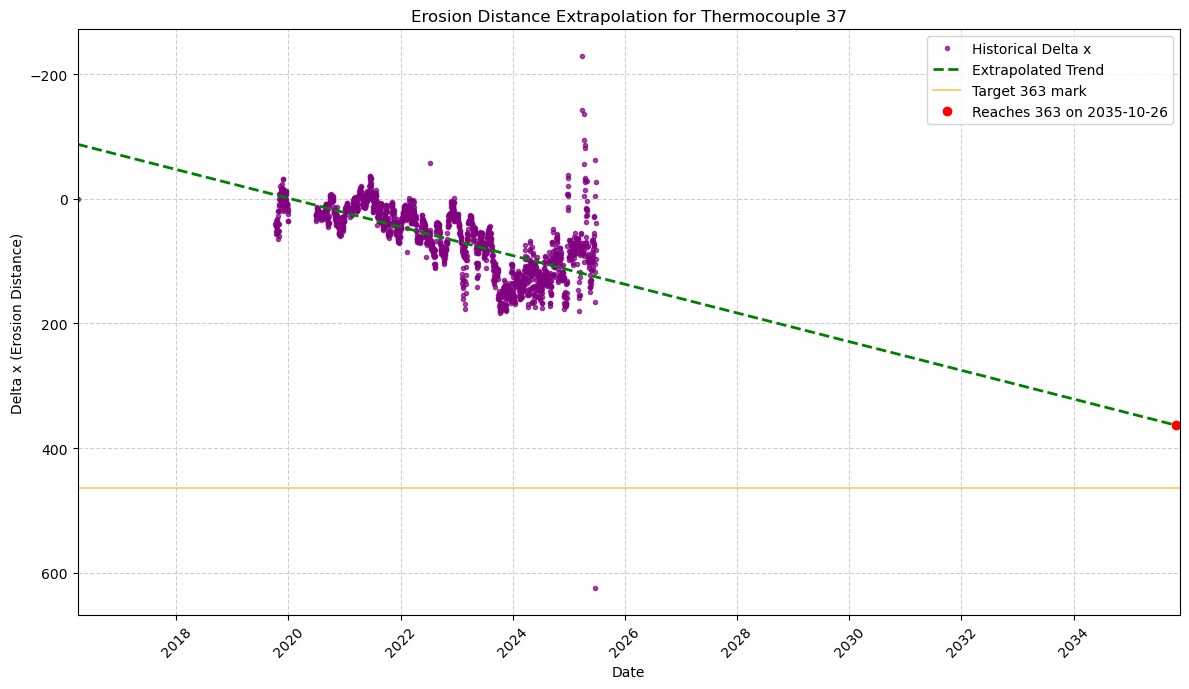

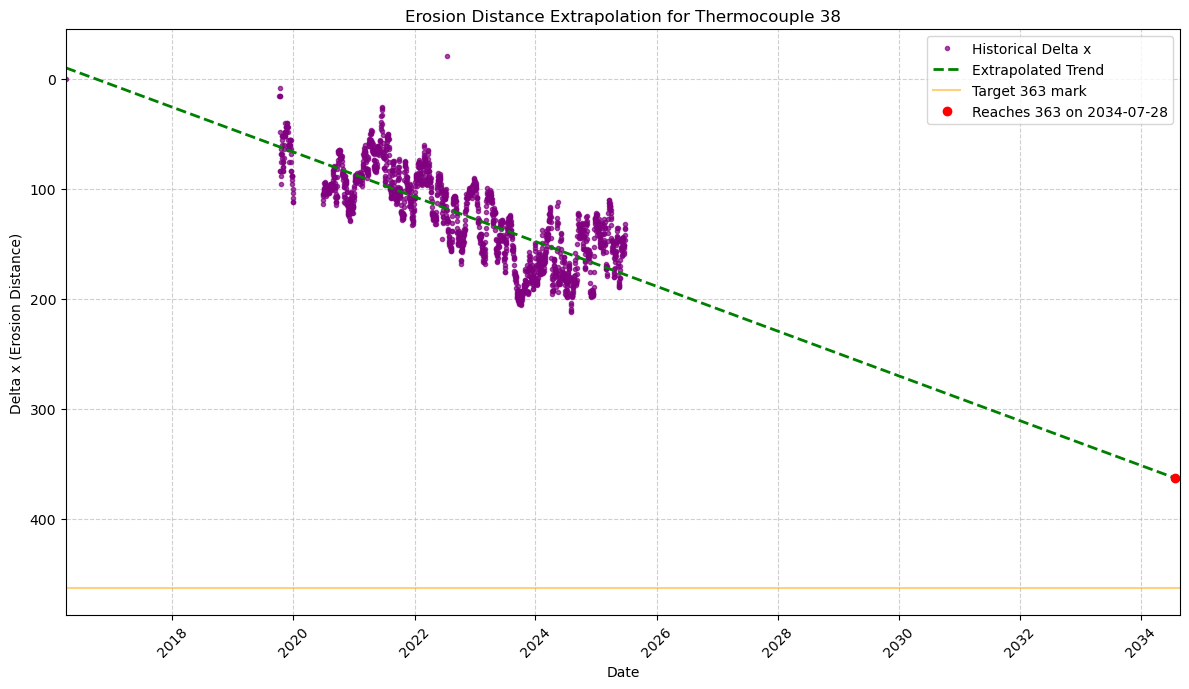

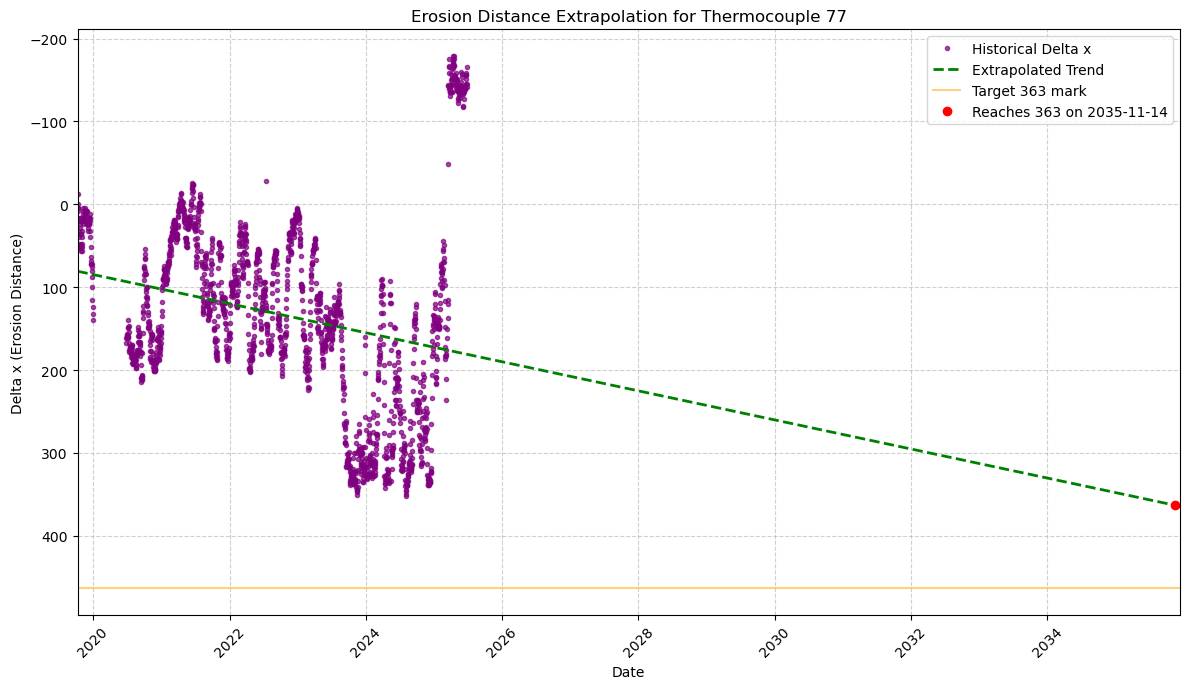

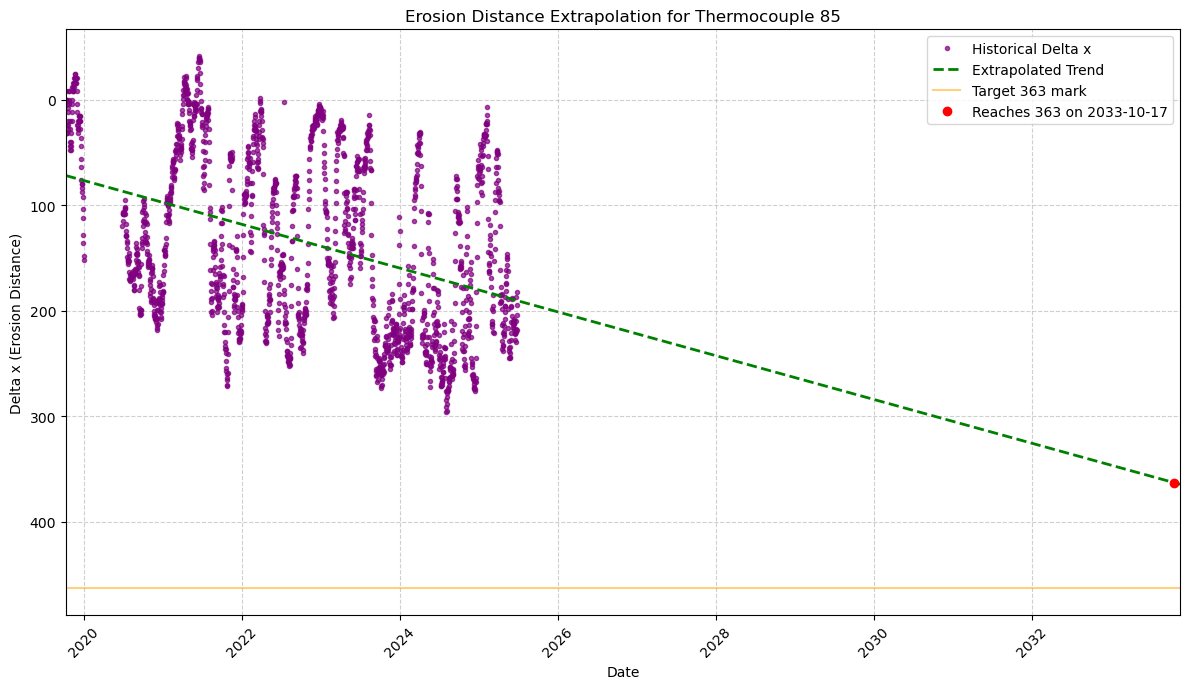

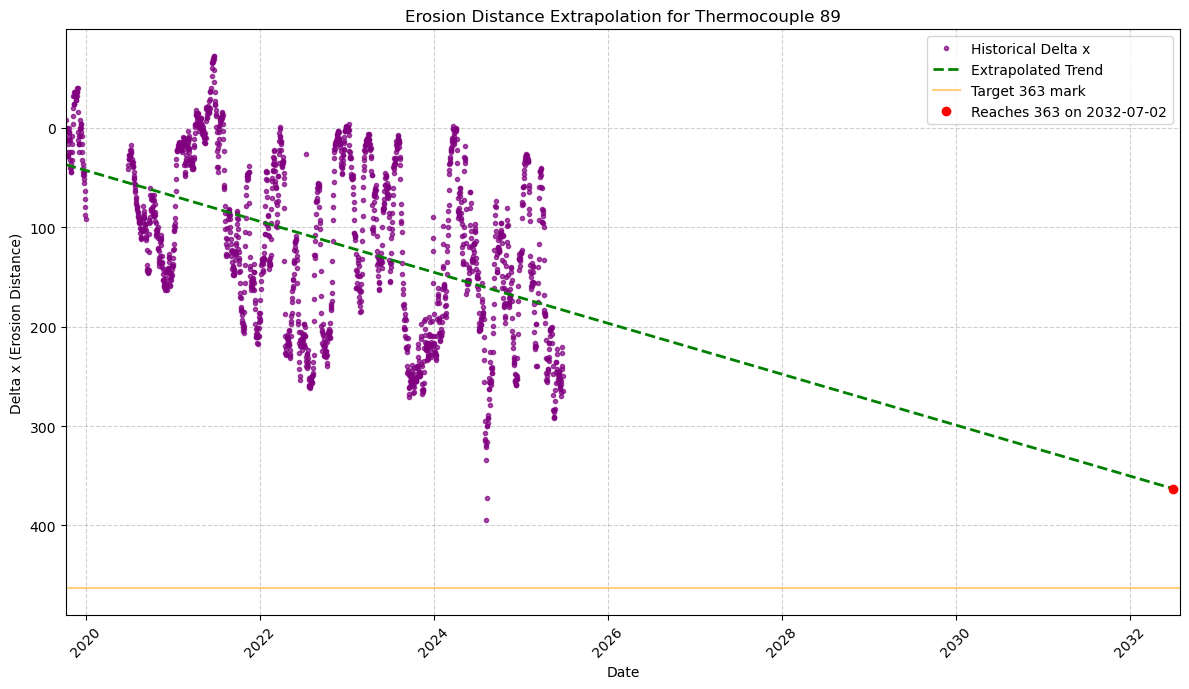

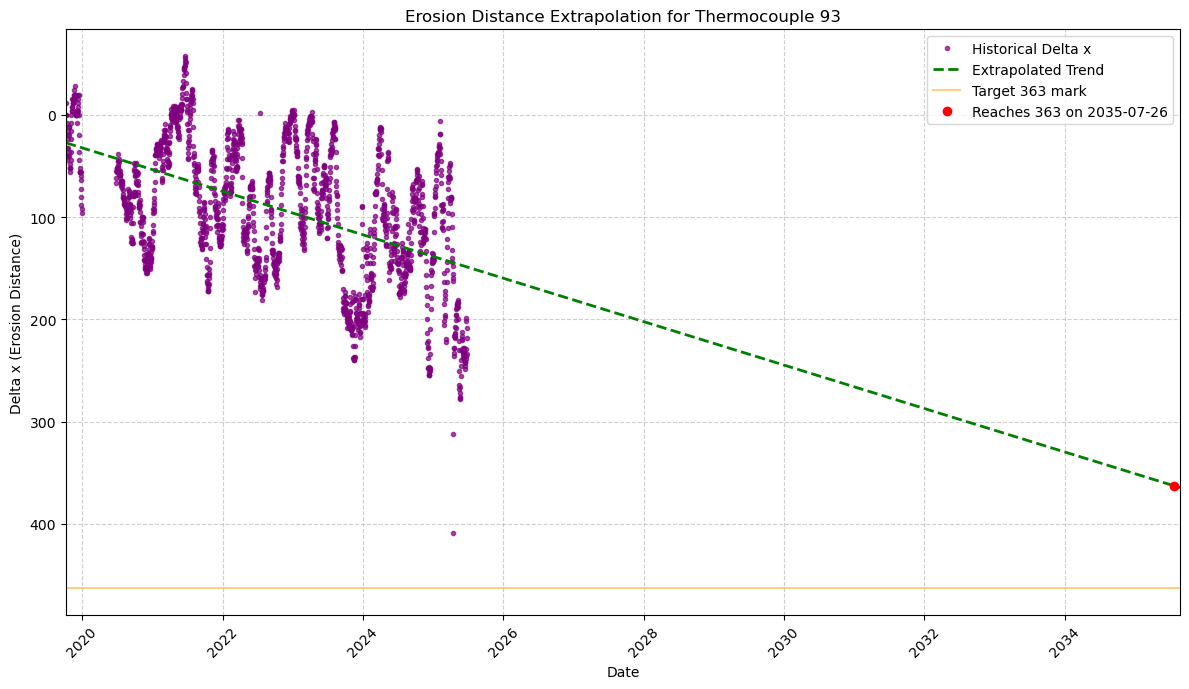

Erosion trend is negative or flat for thermocouple 183, will not reach 363.


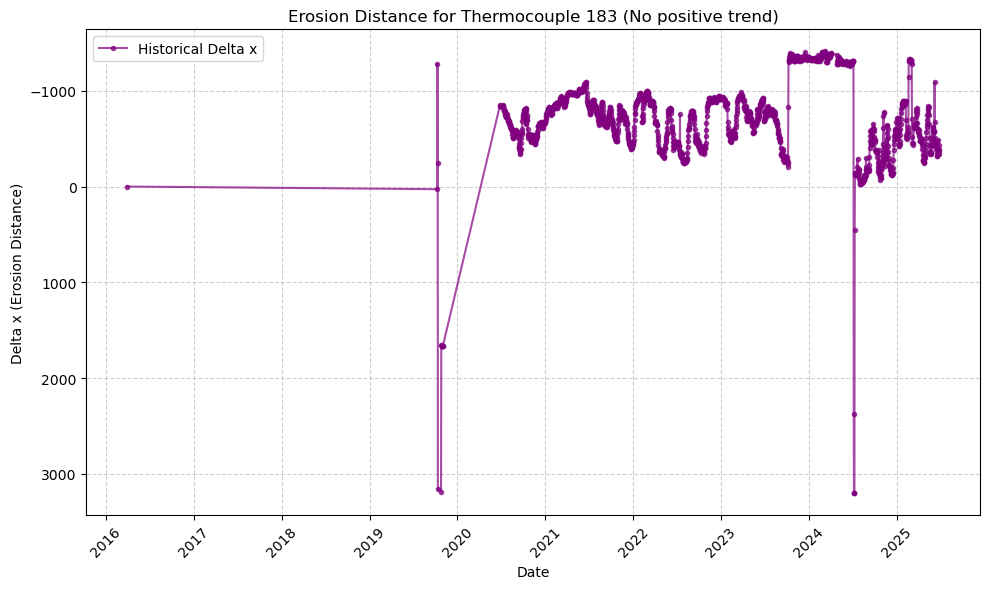

Erosion trend is negative or flat for thermocouple 191, will not reach 363.


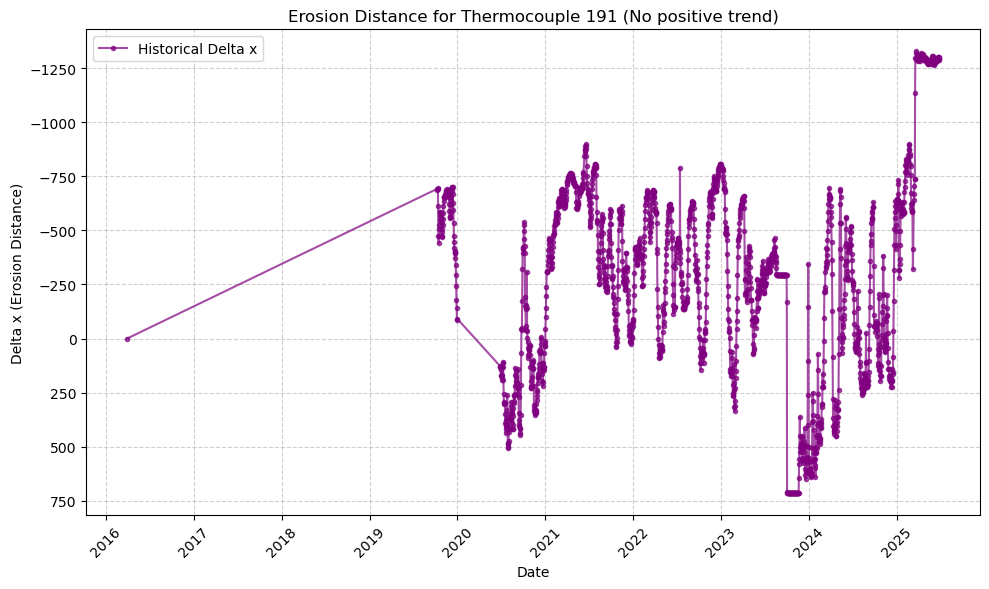

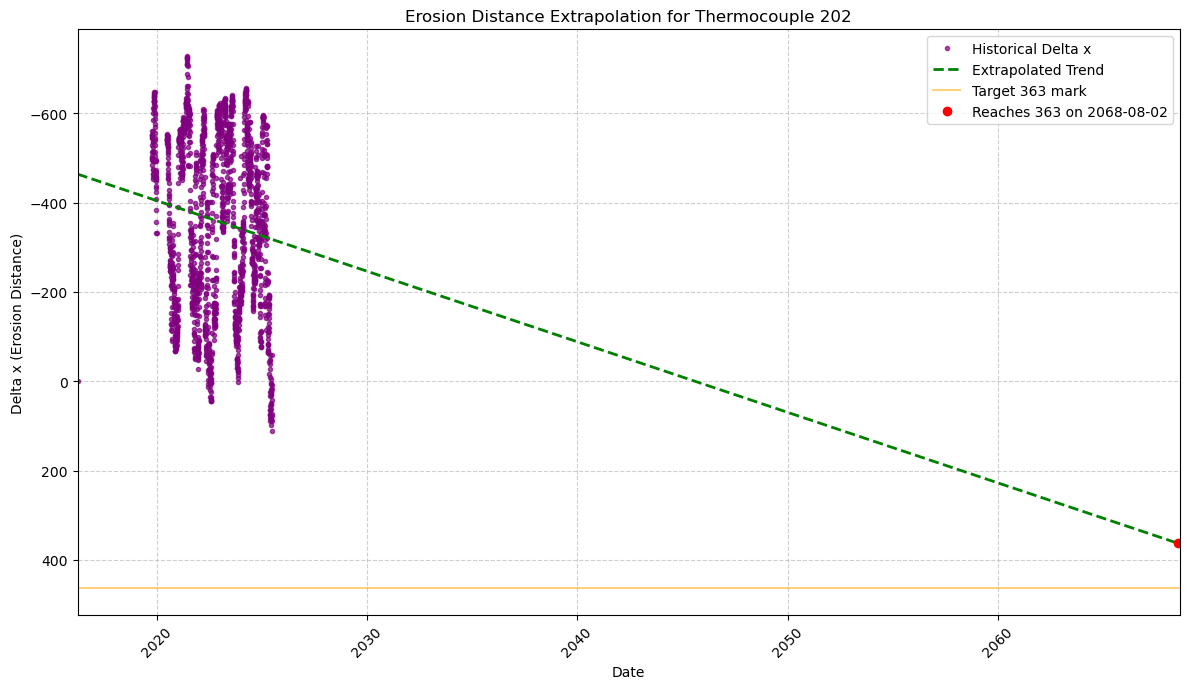

In [12]:
# Code to plot and extrapolate Delta x (erosion distance) vs time for multiple user-defined thermocouples
# Formula: Delta T / 0.25 = delta x
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

user_input = input("Enter Thermocouple Sl. No. separated by commas (e.g., 101, 102, 103): ")
try:
    if user_input.strip():
        user_tc_list = [int(x.strip()) for x in user_input.split(',')] 
    else:
        user_tc_list = []
except ValueError:
    print("Please enter valid integers separated by commas.")
    user_tc_list = []

if user_tc_list and 'df' in globals():
    for user_tc in user_tc_list:
        if user_tc in df["Sl. No."].values:
            # Filter data for this thermocouple
            tc_data_user = df[df["Sl. No."] == user_tc].sort_values("MEASUREDATE").dropna(subset=["VALUE"]).copy()
            
            if len(tc_data_user) > 1:
                initial_temp = tc_data_user["VALUE"].iloc[0]
                tc_data_user["Delta_T"] = tc_data_user["VALUE"] - initial_temp
                tc_data_user["Delta_x"] = tc_data_user["Delta_T"] / 0.25
                
                first_date = tc_data_user["MEASUREDATE"].min()
                tc_data_user["Days"] = (tc_data_user["MEASUREDATE"] - first_date).dt.days
                
                X = tc_data_user[["Days"]].values
                y = tc_data_user["Delta_x"].values
                
                model_lr = LinearRegression()
                model_lr.fit(X, y)
                m = model_lr.coef_[0]
                c = model_lr.intercept_
                
                if m > 1e-9:
                    days_to_target = (363 - c) / m
                    target_date = first_date + pd.Timedelta(days=float(days_to_target))
                    
                    end_date = max(tc_data_user["MEASUREDATE"].max(), target_date)
                    forecast_days = (end_date - first_date).days
                    
                    # Create extrapolation points until a little past the target date
                    X_extrap = np.arange(0, forecast_days + 30).reshape(-1, 1)
                    y_extrap = model_lr.predict(X_extrap)
                    dates_extrap = [first_date + pd.Timedelta(days=float(d)) for d in X_extrap.flatten()]
                    
                    plt.figure(figsize=(12, 7))
                    plt.plot(tc_data_user["MEASUREDATE"], tc_data_user["Delta_x"], marker='.', linestyle='none', color='purple', alpha=0.7, label='Historical Delta x')
                    plt.plot(dates_extrap, y_extrap, linestyle='--', color='green', label="Extrapolated Trend", linewidth=2)
                    
                    plt.axhline(y=463, color='orange', linestyle='-', alpha=0.5, label="Target 363 mark")
                    plt.plot(target_date, 363, 'ro', label=f"Reaches 363 on {target_date.strftime('%Y-%m-%d')}")
                    
                    plt.xlabel("Date")
                    plt.ylabel("Delta x (Erosion Distance)")
                    plt.title(f"Erosion Distance Extrapolation for Thermocouple {user_tc}")
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    plt.xticks(rotation=45)
                    plt.xlim(min(dates_extrap), max(dates_extrap))
                    plt.gca().invert_yaxis()  # Invert Y-axis so erosion visually progresses downwards
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"Erosion trend is negative or flat for thermocouple {user_tc}, will not reach 363.")
                    plt.figure(figsize=(10, 6))
                    plt.plot(tc_data_user["MEASUREDATE"], tc_data_user["Delta_x"], marker='.', linestyle='-', color='purple', alpha=0.7, label='Historical Delta x')
                    plt.xlabel("Date")
                    plt.ylabel("Delta x (Erosion Distance)")
                    plt.title(f"Erosion Distance for Thermocouple {user_tc} (No positive trend)")
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    plt.xticks(rotation=45)
                    plt.gca().invert_yaxis()  # Invert Y-axis so erosion visually progresses downwards
                    plt.tight_layout()
                    plt.show()
            else:
                print(f"Not enough valid data for thermocouple {user_tc} to perform regression.")
        else:
            print(f"Thermocouple {user_tc} not found in the dataset.")
elif user_tc_list and 'df' not in globals():
    print("Dataframe 'df' is not defined. Please run the previous cell first.")
